In [3]:
# Exercise 1: Duplicate Detection and Removal - Titanic Dataset

# Step 1: Import necessary libraries
import pandas as pd

# Step 2: Load the Titanic dataset

df = pd.read_csv('/content/Titanic-Dataset.csv')

# Step 3: Display the number of rows before removing duplicates
print("Number of rows before removing duplicates:", len(df))

# Step 4: Check for duplicate rows
duplicates = df.duplicated()
print("Number of duplicate rows found:", duplicates.sum())

# Step 5: Remove duplicate rows
df_cleaned = df.drop_duplicates()

# Step 6: Display the number of rows after removing duplicates
print("Number of rows after removing duplicates:", len(df_cleaned))

# Optional: Preview the cleaned dataset
print("\nFirst 5 rows of the cleaned dataset:")
print(df_cleaned.head())

Number of rows before removing duplicates: 891
Number of duplicate rows found: 0
Number of rows after removing duplicates: 891

First 5 rows of the cleaned dataset:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        

In [14]:
# Exercise 2: Handling Missing Values
# Step 1: Import necessary libraries
import pandas as pd
from sklearn.impute import SimpleImputer

# Step 2: Load the Titanic dataset
df = pd.read_csv('/content/Titanic-Dataset.csv')

# print data
print(f"original data{df.head()}:\n")
# Step 3: Check for missing values in each column
print("Missing values per column:\n")
print(df.isnull().sum())

# Strategy 1: Remove rows with missing 'Cabin' (too many missing values)
# 'Cabin' is often missing and may not be essential for basic analysis
df_dropped = df.drop(columns=['Cabin'])

# Strategy 2: Impute missing 'Age' with the median
# Age is numeric and can affect survival, so imputing is better than dropping
age_imputer = SimpleImputer(strategy='median')
df_dropped['Age'] = age_imputer.fit_transform(df_dropped[['Age']])

# Strategy 3: Fill missing 'Embarked' values with the most frequent value
# 'Embarked' is categorical; using mode (most frequent value)
embarked_imputer = SimpleImputer(strategy='most_frequent')
df_dropped['Embarked'] = embarked_imputer.fit_transform(df_dropped[['Embarked']]).ravel()#dois aplatir le tableau retourné avec .ravel() ou simplement retransformer le résultat en Series

# Step 4: Check again for any remaining missing values
print("\nRemaining missing values after handling:\n")
print(df_dropped.isnull().sum())

# Step 5: Display the cleaned dataset's first few rows
print("\nPreview of the cleaned dataset:")
print(df_dropped.head())


original data   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN 

In [18]:
##Exercise 3: Feature Engineering
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Étape 1 : Charger les données
df = pd.read_csv('/content/Titanic-Dataset.csv')
print(f"données originales\n", df.head)
# --- Étape 2 : Créer des nouvelles features ---

# 1. Family Size (nombre total de membres de la famille à bord)
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1  # +1 pour inclure la personne elle-même

# 2. Extraire le titre de la colonne Name
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# Regrouper certains titres rares pour simplifier
df['Title'] = df['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr',
                                   'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
df['Title'] = df['Title'].replace('Mlle', 'Miss')
df['Title'] = df['Title'].replace('Ms', 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')

# --- Étape 3 : Encoder les colonnes catégorielles ---

# Utiliser LabelEncoder pour les colonnes avec peu de catégories
label = LabelEncoder()
df['Sex'] = label.fit_transform(df['Sex'])        # Male=1, Female=0
df['Embarked'] = label.fit_transform(df['Embarked'].astype(str))  # C=0, Q=1, S=2
df['Title'] = label.fit_transform(df['Title'])

# --- Étape 4 : Standardisation des variables numériques ---

scaler = StandardScaler()
df[['Age', 'Fare', 'FamilySize']] = scaler.fit_transform(df[['Age', 'Fare', 'FamilySize']])

# --- Étape 5 : Affichage pour vérification ---
print(df[['Sex', 'Embarked', 'Title', 'FamilySize']].head())
print("\nColonnes numériques standardisées :")
print(df[['Age', 'Fare', 'FamilySize']].describe())

données originales
 <bound method NDFrame.head of      PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                 

              Age        Fare
count  714.000000  891.000000
mean    29.699118   32.204208
std     14.526497   49.693429
min      0.420000    0.000000
25%     20.125000    7.910400
50%     28.000000   14.454200
75%     38.000000   31.000000
max     80.000000  512.329200
Outliers in Age: 11
Outliers in Fare: 116


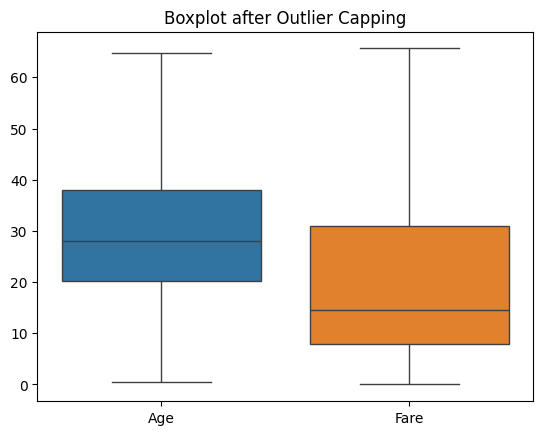

              Age        Fare
count  714.000000  891.000000
mean    29.622700   24.046813
std     14.316665   20.481625
min      0.420000    0.000000
25%     20.125000    7.910400
50%     28.000000   14.454200
75%     38.000000   31.000000
max     64.812500   65.634400


In [24]:
#Exercise 4: Outlier Detection and Handling

import pandas as pd
import numpy as np
#Step 1: Load the Titanic Dataset
#---------------------------------
# Load the Titanic dataset
df = pd.read_csv('/content/Titanic-Dataset.csv')

# Check relevant columns
print(df[['Age', 'Fare']].describe())
#Step 2: Detect Outliers Using IQR Method
#I'll use the Interquartile Range (IQR) method to find outliers in Age and Fare.
#---------------------------------
def detect_outliers_iqr(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower) | (df[column] > upper)]
    return outliers

# Detect outliers in Age and Fare
outliers_age = detect_outliers_iqr('Age')
outliers_fare = detect_outliers_iqr('Fare')

print(f"Outliers in Age: {len(outliers_age)}")
print(f"Outliers in Fare: {len(outliers_fare)}")
#Step 3: Handle Outliers — Capping
def cap_outliers(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[column] = np.where(df[column] > upper, upper,
                          np.where(df[column] < lower, lower, df[column]))

import matplotlib.pyplot as plt
import seaborn as sns
# Apply capping
cap_outliers('Age')
cap_outliers('Fare')
#Step 4: Visualize the Effect
# Boxplot before and after capping
sns.boxplot(data=df[['Age', 'Fare']])
plt.title("Boxplot after Outlier Capping")
plt.show()
#Step 5: Assess Impact
print(df[['Age', 'Fare']].describe())

In [26]:
#Exercise 5: Data Standardization and Normalization
# Step 1: Import necessary libraries
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Step 2: Load Titanic dataset
df = pd.read_csv('/content/Titanic-Dataset.csv')  # Remplacez par le chemin correct si besoin

# Step 3: Select numerical features for scaling
numerical_features = ['Age', 'Fare']

# Drop rows with missing numerical data for this exercise
df = df[numerical_features].dropna()

# Step 4: Apply Standardization (Z-score scaling) for features with wide ranges
standard_scaler = StandardScaler()
df_standardized = pd.DataFrame(
    standard_scaler.fit_transform(df[['Age', 'Fare']]),
    columns=['Age_standardized', 'Fare_standardized']
)

# Step 5: Apply Min-Max Normalization (to range [0, 1])
min_max_scaler = MinMaxScaler()
df_normalized = pd.DataFrame(
    min_max_scaler.fit_transform(df[['Age', 'Fare']]),
    columns=['Age_normalized', 'Fare_normalized']
)

# Step 6: Combine original and transformed data for comparison
df_combined = pd.concat([df.reset_index(drop=True), df_standardized, df_normalized], axis=1)

# Step 7: Display the first few rows
print(df_combined.head())


    Age     Fare  Age_standardized  Fare_standardized  Age_normalized  \
0  22.0   7.2500         -0.530377          -0.518978        0.271174   
1  38.0  71.2833          0.571831           0.691897        0.472229   
2  26.0   7.9250         -0.254825          -0.506214        0.321438   
3  35.0  53.1000          0.365167           0.348049        0.434531   
4  35.0   8.0500          0.365167          -0.503850        0.434531   

   Fare_normalized  
0         0.014151  
1         0.139136  
2         0.015469  
3         0.103644  
4         0.015713  


In [31]:
#Exercise 6: Feature Encoding# Étape 1 : Importation des bibliothèques
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Étape 2 : Charger le dataset Titanic
df = pd.read_csv("/content/Titanic-Dataset.csv")  # Remplacez par le chemin de votre fichier si besoin

# Étape 3 : Afficher les colonnes catégorielles
print("Colonnes catégorielles :", df.select_dtypes(include='object').columns.tolist())

# Étape 4 : Gestion des valeurs manquantes dans les colonnes catégorielles
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Étape 5 : Encodage one-hot des variables nominales
df_encoded = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)

# Étape 6 : Label encoding pour la variable 'Pclass' si on la considère comme ordinale
# (optionnel, car souvent Pclass est déjà numérique, mais on peut transformer une autre variable si besoin)
# Ici, aucune variable textuelle ordinale claire n’est présente, donc on saute le label encoding.

# Étape 7 : Afficher les colonnes finales
print("Colonnes après encodage :", df_encoded.columns.tolist())
print(df_encoded.head())

Colonnes catégorielles : ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']
Colonnes après encodage : ['PassengerId', 'Survived', 'Pclass', 'Name', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Sex_male', 'Embarked_Q', 'Embarked_S']
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name   Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris  22.0      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  38.0      1      0   
2                             Heikkinen, Miss. Laina  26.0      0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  35.0      1      0   
4                           Allen, Mr. William Henry  35.0      0      0   

             Ticket     Fare Cabin  Sex_male  Embarked_Q  Embarked_S  
0         A/5 21171

<ipython-input-31-1444057028>:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)


In [36]:
#Exercise 7: Data Transformation for Age Feature
import pandas as pd

# 1. Charger le dataset Titanic
df = pd.read_csv("/content/Titanic-Dataset.csv")

# 2. Remplacer les valeurs manquantes dans la colonne 'Age' par la médiane
df['Age'].fillna(df['Age'].median(), inplace=True)

# 3. Définir les tranches d'âge, pour l'exercice j'ai choisi les 4 tranches d'âge suivantes :
#0 à 18 ans → Enfant
#19 à 35 ans → Jeune Adulte
#36 à 60 ans → Adulte
#61 ans et plus → Senior
bins = [0, 18, 35, 60, 100]
labels = ['Enfant', 'Jeune Adulte', 'Adulte', 'Senior']

df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

# 4. Encoder les tranches avec one-hot encoding
age_dummies = pd.get_dummies(df['AgeGroup'], prefix='AgeGroup')

# 5. Ajouter les nouvelles colonnes à la DataFrame d'origine
df = pd.concat([df, age_dummies], axis=1)

# 6. Afficher un extrait pour vérification
print(df[['Age', 'AgeGroup'] + list(age_dummies.columns)].head())

    Age      AgeGroup  AgeGroup_Enfant  AgeGroup_Jeune Adulte  \
0  22.0  Jeune Adulte            False                   True   
1  38.0        Adulte            False                  False   
2  26.0  Jeune Adulte            False                   True   
3  35.0  Jeune Adulte            False                   True   
4  35.0  Jeune Adulte            False                   True   

   AgeGroup_Adulte  AgeGroup_Senior  
0            False            False  
1             True            False  
2            False            False  
3            False            False  
4            False            False  


<ipython-input-36-451331611>:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
